<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Fluid_Dynamics_ISAT_Example_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

This notebook implements a high-performance computational framework designed to accelerate the evaluation of stiff chemical reaction source terms using In Situ Adaptive Tabulation (ISAT). The architecture leverages Graphics Processing Unit (GPU) acceleration through the CuPy library (a NumPy-compatible array library for CUDA) to manage the intensive state-space mapping required for large-scale kinetics simulations.

# ISAT-Accelerated Chemical Kinetics Simulation

### Theoretical Foundation and Primer
The simulation addresses the computational bottleneck inherent in reacting flow simulations, where the integration of stiff Ordinary Differential Equations (ODEs) often consumes the vast majority of processing time. Instead of performing a full numerical integration for every spatial point at every time step, In Situ Adaptive Tabulation (ISAT) constructs a dynamic lookup table (a database of previously resolved states) during the simulation.

When the solver encounters a new temperature state, it performs a nearest-neighbor search within the existing table; furthermore, if the distance to a stored state is within a predefined error tolerance ($\epsilon$), the solver retrieves the stored result (a "table hit"). If the state is novel or outside the tolerance (a "table miss"), the framework invokes a robust Runge-Kutta 4th Order (RK4) numerical method to resolve the chemistry and subsequently populates the table with this new data.

### Algorithmic Architecture
The primary logic is encapsulated within the `ISATChemicalSolver` class, which manages the dual-pathway evaluation process.

* **Arrhenius Reaction Rate:** The physics engine utilizes a simplified Arrhenius constant and activation energy ratio to compute reaction rates, which represents the underlying physical complexity being tabulated.
* **RK4 Integrator:** The `_solve_ode` method implements the four-stage Runge-Kutta algorithm; this ensures high-order accuracy during the integration of the source term over the discrete time step ($\Delta t$).
* **State-Space Mapping:** The `evaluate` method orchestrates the tabulation logic by calculating absolute distances between query points and the tabulated manifold; consequently, the system effectively "learns" the reaction manifold as the simulation progresses.

### Simulation Configuration (Control Knobs)
The framework provides several parameters for fine-tuning the balance between computational speed and numerical precision.

| Parameter | Symbol | Description |
| :--- | :--- | :--- |
| Simulation Points | $N$ | The total number of discrete temperature states evaluated in the run. |
| Error Tolerance | $\epsilon$ | The maximum allowable distance for a table hit (controls accuracy). |
| Time Step | $\Delta t$ | The integration interval for the Runge-Kutta numerical solver. |
| Temperature Range | $[\phi_{min}, \phi_{max}]$ | The thermal boundaries (in Kelvin) for the uniform distribution of query states. |

### Performance and Visualization
Upon execution, the script generates a performance summary detailing the algorithmic efficiency. A high "Hit Rate" indicates that the ISAT table is successfully approximating the reaction manifold, which significantly reduces the total number of expensive ODE calls. The resulting visualization displays the reaction rate across the temperature spectrum, where the color gradient denotes the temporal progression (iteration index) of the tabulation process.

The notebook provides a functional implementation of a GPU-accelerated In Situ Adaptive Tabulation (ISAT) solver that uses 4th-order Runge-Kutta (RK4) integration to efficiently map Arrhenius reaction rates.

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 90ms
=== ISAT Performance Summary ===
Total Grid Points: 1000
ODE Calls (Misses): 754
Table Hits: 246
Hit Rate: 24.60%


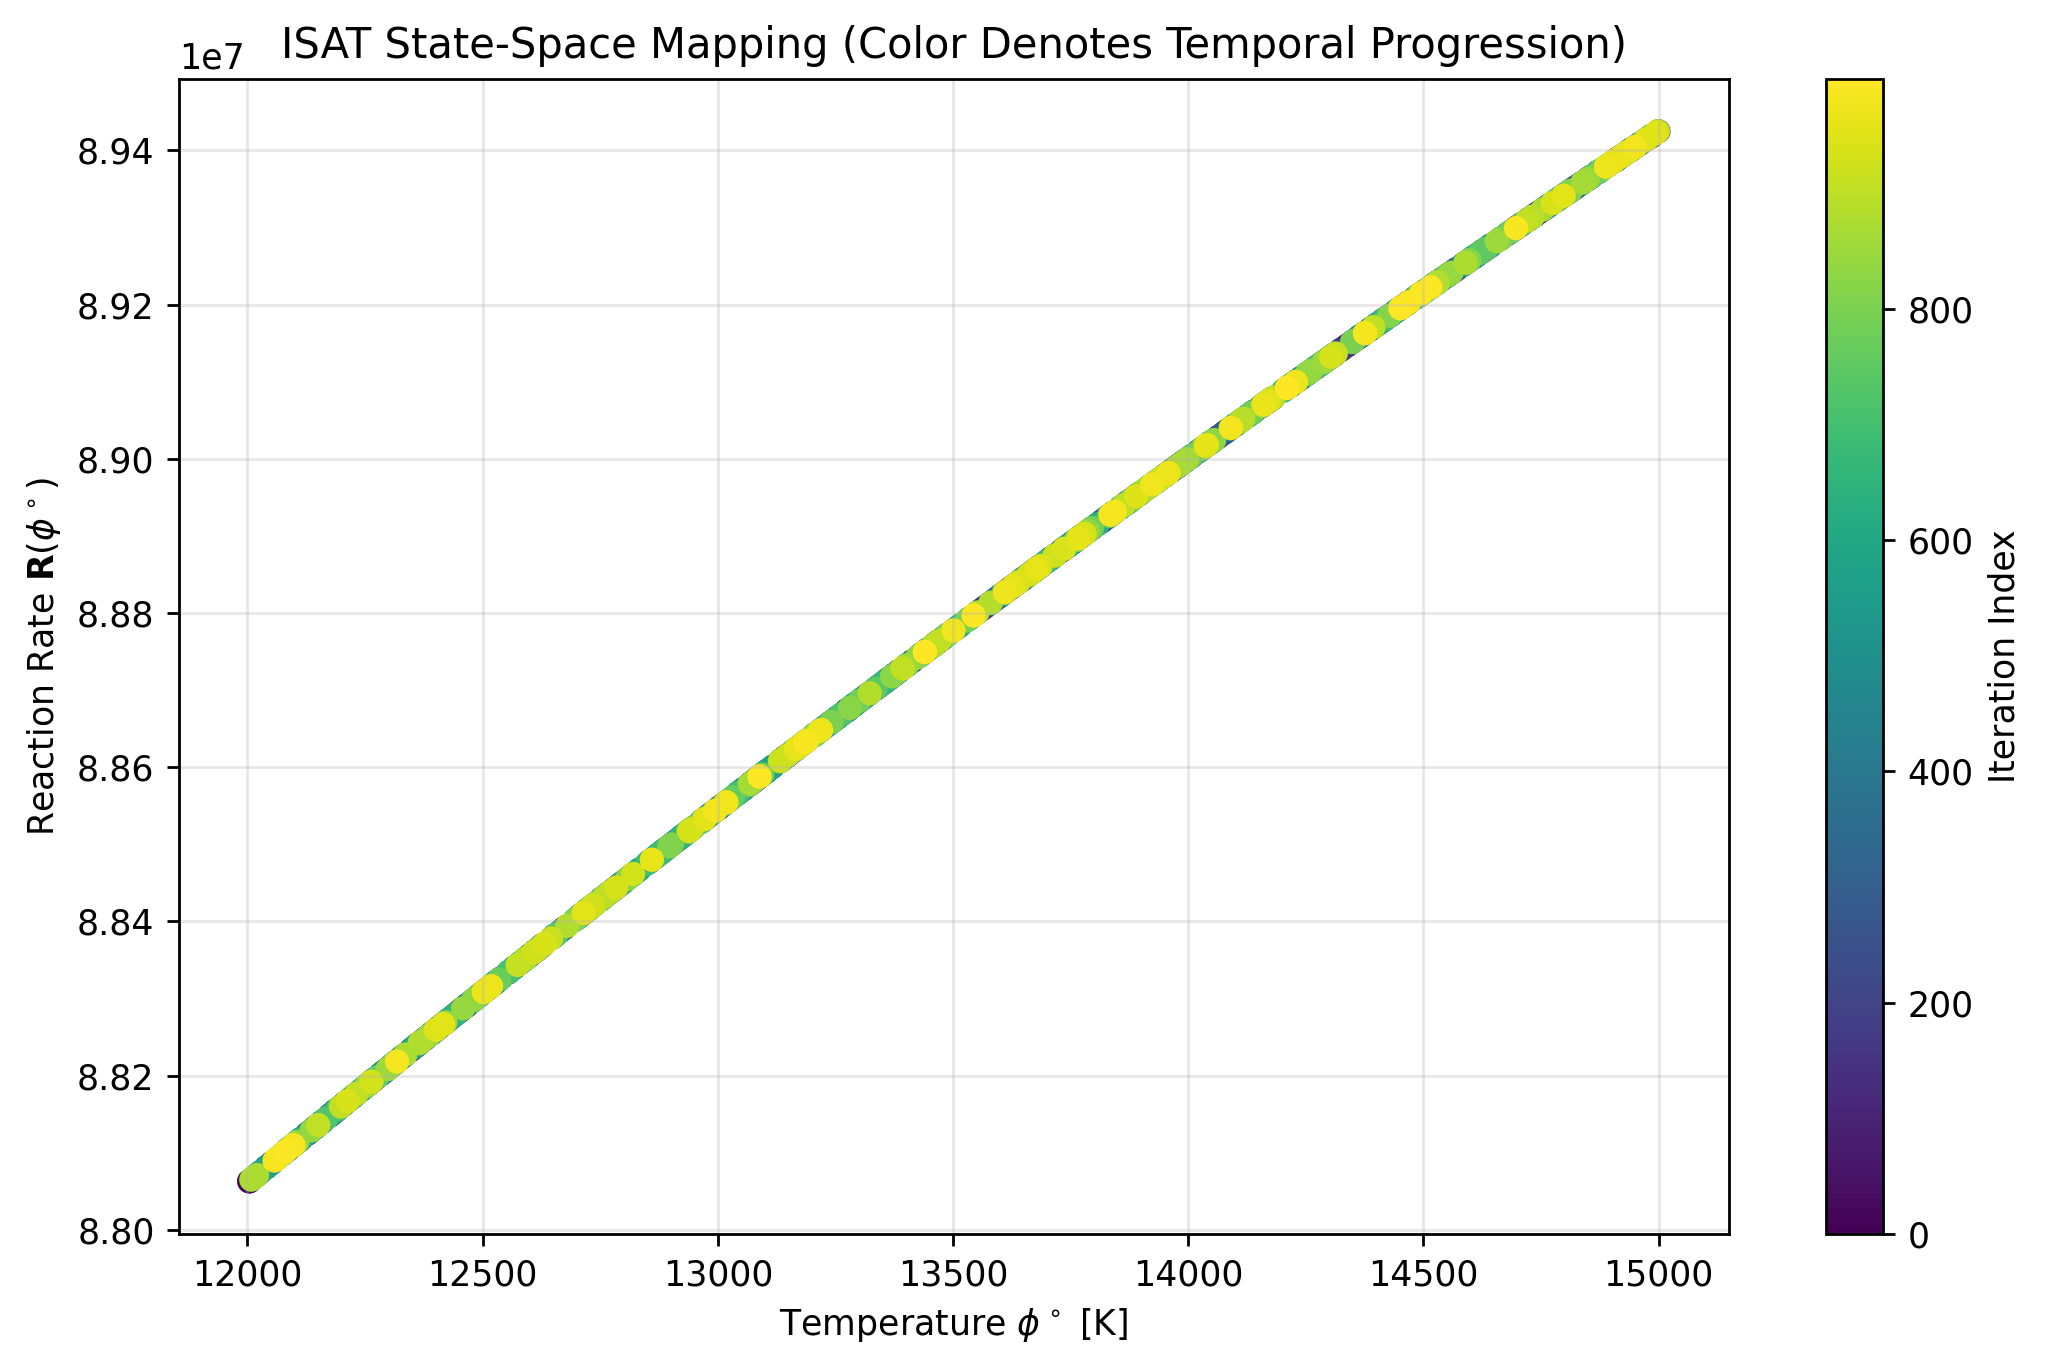

In [ ]:
!uv pip install cupy-cuda12x matplotlib numpy

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 250

# ==========================================
# CONTROL KNOBS
# ==========================================
SIMULATION_POINTS = 1000
TEMP_MIN = 12000.0       # Minimum boundary for uniform temperature distribution [K]
TEMP_MAX = 15000.0       # Maximum boundary for uniform temperature distribution [K]
ERROR_TOLERANCE = 1.0    # Epsilon tolerance for In Situ Adaptive Tabulation table hits
ODE_TIME_STEP = 0.01     # Integration time step for the Runge Kutta 4th Order solver
# ==========================================

class ISATChemicalSolver:
    """
    A simplified In Situ Adaptive Tabulation implementation.

    This class simulates the acceleration of a chemical source term
    evaluation utilizing a Graphics Processing Unit accelerated
    lookup table alongside an Ordinary Differential Equation integrator.
    """

    def __init__(self, tolerance: float = 1e-2, dt: float = 0.01):
        """
        Initialize the chemical solver configuration.

        Args:
            tolerance (float): The error tolerance epsilon for table hits.
            dt (float): The time step for the integration method.
        """
        self.tolerance = tolerance
        self.dt = dt

        self.table_states = cp.array([], dtype=cp.float32).reshape(0, 1)
        self.table_values = cp.array([], dtype=cp.float32).reshape(0, 1)

        self.ode_calls = 0
        self.table_hits = 0

    def reaction_rate(self, current_temperature: cp.ndarray) -> cp.ndarray:
        """
        Compute a simplified Arrhenius reaction rate representing the computationally expensive physics step.

        Args:
            current_temperature (cp.ndarray): The current temperature state field.

        Returns:
            cp.ndarray: The evaluated reaction rate array.
        """
        arrhenius_constant = 1.0e10
        activation_energy_ratio = 15000.0
        return arrhenius_constant * cp.exp(-activation_energy_ratio / current_temperature)

    def _solve_ode(self, initial_temperature: cp.ndarray) -> cp.ndarray:
        """
        Perform a stiff-simulated integration utilizing the numerical method over the specified time step.

        Args:
            initial_temperature (cp.ndarray): The initial temperature state prior to integration.

        Returns:
            cp.ndarray: The resulting source term temperature differential.
        """
        self.ode_calls += 1

        def rate_function(temp_val: cp.ndarray) -> cp.ndarray:
            return self.reaction_rate(temp_val)

        k1 = rate_function(initial_temperature)
        k2 = rate_function(initial_temperature + 0.5 * self.dt * k1)
        k3 = rate_function(initial_temperature + 0.5 * self.dt * k2)
        k4 = rate_function(initial_temperature + self.dt * k3)

        integrated_result = initial_temperature + (self.dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        return integrated_result - initial_temperature

    def evaluate(self, query_temperature: cp.ndarray) -> cp.ndarray:
        """
        Evaluate the reaction source term applying the established tabulation logic.

        Args:
            query_temperature (cp.ndarray): The current query temperature state.

        Returns:
            cp.ndarray: The evaluated reaction source term differential.
        """
        if self.table_states.size > 0:
            distances = cp.abs(self.table_states - query_temperature)
            minimum_index = cp.argmin(distances)

            if distances[minimum_index] < self.tolerance:
                self.table_hits += 1
                return self.table_values[minimum_index]

        resolved_value = self._solve_ode(query_temperature)

        self.table_states = cp.vstack([self.table_states, query_temperature])
        self.table_values = cp.vstack([self.table_values, resolved_value])

        return resolved_value


def run_simulation() -> None:
    """
    Execute the main simulation process to demonstrate computational algorithmic efficiency.
    """
    temperature_states = cp.random.uniform(TEMP_MIN, TEMP_MAX, SIMULATION_POINTS).reshape(-1, 1)
    isat_solver = ISATChemicalSolver(tolerance=ERROR_TOLERANCE, dt=ODE_TIME_STEP)

    results = []
    for i in range(SIMULATION_POINTS):
        computed_value = isat_solver.evaluate(temperature_states[i])
        results.append(computed_value)

    results_array = cp.vstack(results)

    efficiency_hit_rate = (isat_solver.table_hits / SIMULATION_POINTS) * 100

    print("=== ISAT Performance Summary ===")
    print(f"Total Grid Points: {SIMULATION_POINTS}")
    print(f"ODE Calls (Misses): {isat_solver.ode_calls}")
    print(f"Table Hits: {isat_solver.table_hits}")
    print(f"Hit Rate: {efficiency_hit_rate:.2f}%")

    plt.figure(figsize=(10, 6))
    plt.scatter(temperature_states.get(), results_array.get(), c=np.arange(SIMULATION_POINTS), cmap='viridis')
    plt.colorbar(label='Iteration Index')

    plt.xlabel(r'Temperature $\phi^\circ$ [K]')
    # The unsupported underline macro is replaced with standard bolding for mathtext compatibility
    plt.ylabel(r'Reaction Rate $\mathbf{R}(\phi^\circ)$')
    plt.title('ISAT State-Space Mapping (Color Denotes Temporal Progression)')
    plt.grid(True, alpha=0.3)

    plt.show()

if __name__ == "__main__":
    run_simulation()

Using Python 3.12.13 environment at: /usr
Checked 4 packages in 88ms


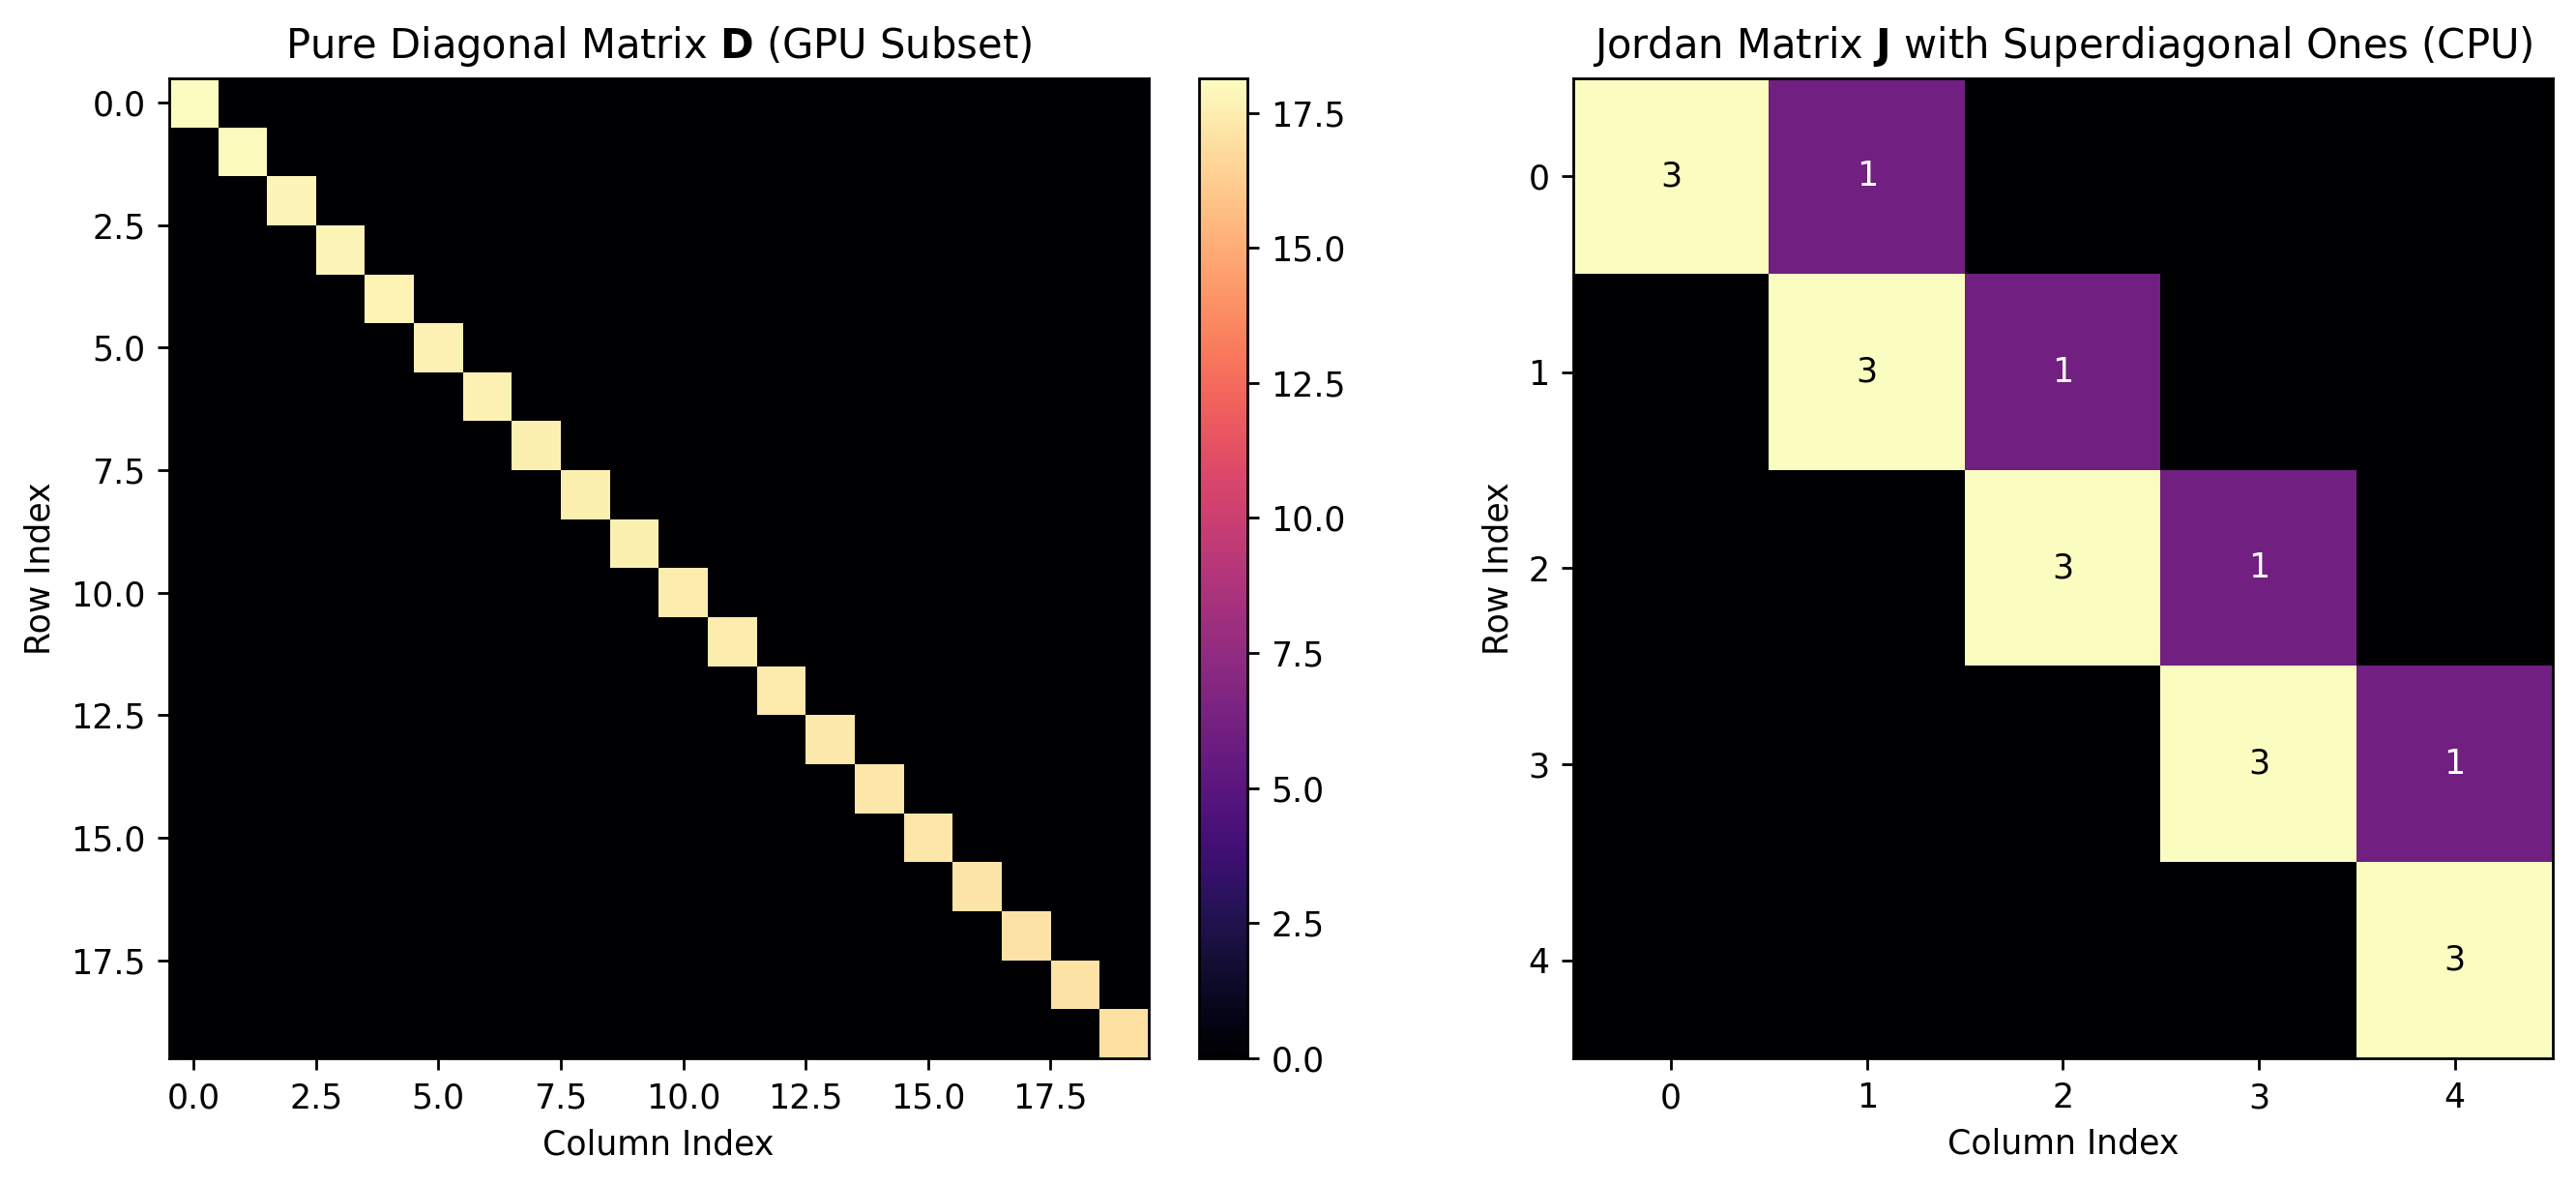

In [ ]:
!uv pip install cupy-cuda12x sympy numpy matplotlib

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from matplotlib import rc

# =============================================================================
# CONTROL KNOBS: Experimental Configuration Parameters
# =============================================================================
# GPU Parameters for numerical diagonalization
GPU_MATRIX_SIZE = 2000          # Dimensionality of the symmetric diagonalizable matrix
GPU_RANDOM_SEED = 42            # Seed for reproducible random matrix generation

# CPU Parameters for symbolic Jordan block decomposition
# The size is kept diminutive because symbolic computation scales factorially
CPU_DEFECTIVE_SIZE = 5
# =============================================================================

class MatrixDecompositionDemonstrator:
    """
    A computational suite designed to highlight the fundamental disparity between
    numerical matrix diagonalization and symbolic Jordan reduction.
    """

    def __init__(self, size_gpu: int, size_cpu: int):
        """
        Initialize the demonstrator with specified dimensionalities.

        Args:
            size_gpu (int): The dimension for the massive numerical array.
            size_cpu (int): The dimension for the exact symbolic array.
        """
        self.size_gpu = size_gpu
        self.size_cpu = size_cpu

    def execute_gpu_diagonalization(self) -> tuple[cp.ndarray, cp.ndarray]:
        """
        Construct a symmetric matrix and perform eigenvalue decomposition
        utilizing highly parallelized hardware acceleration.

        Returns:
            tuple[cp.ndarray, cp.ndarray]: The diagonalized eigenvalue matrix D
                                           and the eigenvector matrix P.
        """
        cp.random.seed(GPU_RANDOM_SEED)

        # Generate a dense symmetric matrix (guaranteed diagonalizable by the Spectral Theorem)
        random_array = cp.random.rand(self.size_gpu, self.size_gpu, dtype=cp.float32)
        symmetric_matrix = 0.5 * (random_array + random_array.T)

        # eigh is optimized for symmetric matrices and returns real eigenvalues
        eigenvalues, eigenvectors = cp.linalg.eigh(symmetric_matrix)

        diagonal_matrix = cp.diag(eigenvalues)

        return diagonal_matrix, eigenvectors

    def execute_cpu_jordan_form(self) -> tuple[sp.Matrix, sp.Matrix]:
        """
        Construct a deliberately defective matrix and compute its Jordan Canonical Form
        utilizing exact symbolic mathematics to bypass floating-point instability.

        Returns:
            tuple[sp.Matrix, sp.Matrix]: The transformation matrix P and the Jordan matrix J.
        """
        # Construct a nilpotent shift matrix serving as a foundational defective structure
        base_matrix = sp.zeros(self.size_cpu, self.size_cpu)
        for i in range(self.size_cpu - 1):
            base_matrix[i, i + 1] = 1

        # Introduce a repeated eigenvalue (lambda = 3) on the primary diagonal
        defective_matrix = base_matrix + 3 * sp.eye(self.size_cpu)

        # Apply a nonsingular transformation to obscure the structure slightly
        # P_obfuscate * A * P_obfuscate_inv
        transformation = sp.eye(self.size_cpu)
        transformation[0, 1] = 2
        transformation[self.size_cpu - 1, 0] = -1

        obfuscated_matrix = transformation * defective_matrix * transformation.inv()

        # Perform the exact symbolic Jordan decomposition
        p_matrix, jordan_matrix = obfuscated_matrix.jordan_form()

        return p_matrix, jordan_matrix

def visualize_decompositions(
    diagonal_matrix_gpu: cp.ndarray,
    jordan_matrix_cpu: sp.Matrix
) -> None:
    """
    Render a comparative visualization illustrating the structural differences
    between pure diagonalization and Jordan block forms.

    Args:
        diagonal_matrix_gpu (cp.ndarray): The diagonalized matrix residing in VRAM.
        jordan_matrix_cpu (sp.Matrix): The exact symbolic Jordan matrix.
    """
    # Extract a diminutive subset of the massive GPU matrix for comparative visual clarity
    subset_size = GPU_MATRIX_SIZE if GPU_MATRIX_SIZE < 20 else 20
    diag_subset = diagonal_matrix_gpu[:subset_size, :subset_size].get()

    # Convert the symbolic matrix to a NumPy float array for Matplotlib compatibility
    jordan_numpy = np.array(jordan_matrix_cpu).astype(np.float64)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: The purely diagonal matrix
    im1 = axes[0].imshow(np.abs(diag_subset), cmap='magma', interpolation='none')
    axes[0].set_title(r'Pure Diagonal Matrix $\mathbf{D}$ (GPU Subset)')
    axes[0].set_xlabel('Column Index')
    axes[0].set_ylabel('Row Index')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Plot 2: The Jordan canonical block structure
    im2 = axes[1].imshow(jordan_numpy, cmap='magma', interpolation='none')
    axes[1].set_title(r'Jordan Matrix $\mathbf{J}$ with Superdiagonal Ones (CPU)')
    axes[1].set_xlabel('Column Index')
    axes[1].set_ylabel('Row Index')

    # Annotate the specific values to highlight the superdiagonal terms visually
    for i in range(jordan_numpy.shape[0]):
        for j in range(jordan_numpy.shape[1]):
            val = jordan_numpy[i, j]
            if val != 0:
                axes[1].text(j, i, f'{val:.0f}', ha='center', va='center',
                             color='white' if val < 2 else 'black')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    demonstrator = MatrixDecompositionDemonstrator(GPU_MATRIX_SIZE, CPU_DEFECTIVE_SIZE)

    # Execute the GPU-accelerated pipeline
    gpu_d, gpu_p = demonstrator.execute_gpu_diagonalization()

    # Execute the symbolic CPU pipeline
    cpu_p, cpu_j = demonstrator.execute_cpu_jordan_form()

    visualize_decompositions(gpu_d, cpu_j)

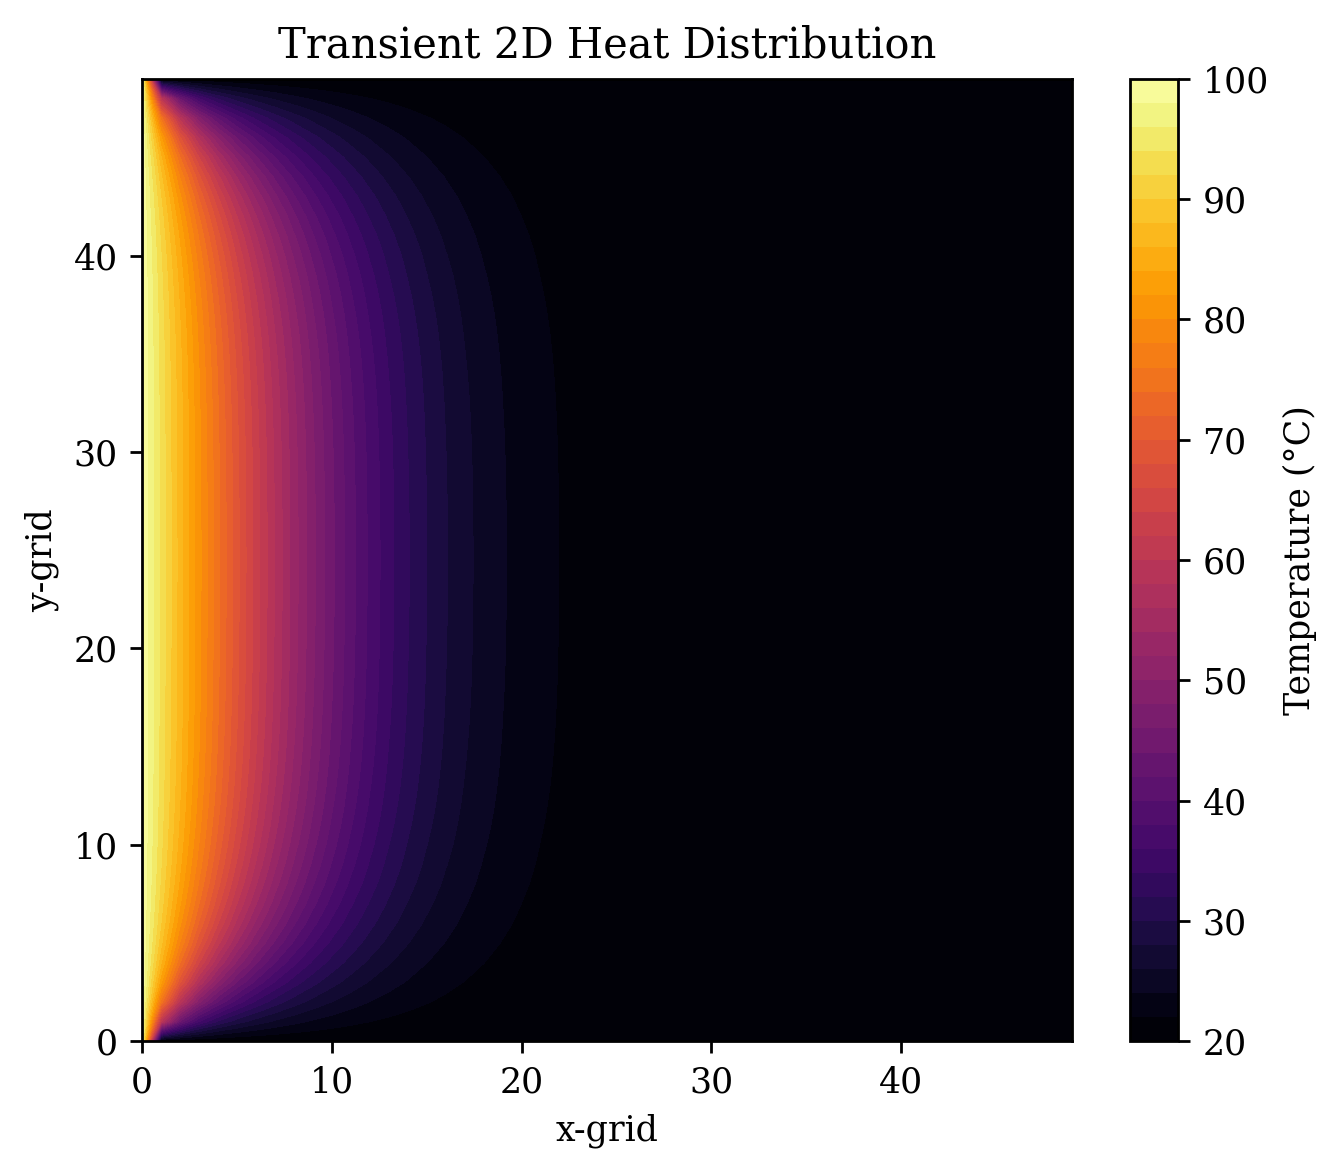

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Control Knobs ---
# Adjustable parameters for the heat transfer simulation
thermal_diffusivity = 0.01  # [m^2/s] (alpha)
plate_length = 1.0         # [m]
plate_width = 1.0          # [m]
nx, ny = 50, 50            # Number of spatial grid points
total_time = 2.0           # [s] Total simulation duration
dt = 0.0005                # [s] Time step (must satisfy stability)
temp_boundary_left = 100.0 # [C] Boundary condition
temp_initial = 20.0        # [C] Initial plate temperature
# ---------------------

# Configure high-resolution rendering for scientific clarity
plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.family'] = 'serif'

def solve_heat_2d():
    """Solve the 2D transient heat equation using an explicit FDM scheme."""
    dx = plate_length / (nx - 1)
    dy = plate_width / (ny - 1)

    # Initialize temperature field
    t_field = np.full((nx, ny), temp_initial)
    t_field[:, 0] = temp_boundary_left  # Apply Dirichlet condition

    # Pre-calculate coefficient
    coeff = thermal_diffusivity * dt / (dx**2)

    # Time-stepping loop
    n_steps = int(total_time / dt)
    for _ in range(n_steps):
        t_new = t_field.copy()
        t_new[1:-1, 1:-1] = t_field[1:-1, 1:-1] + coeff * (
            t_field[2:, 1:-1] - 2*t_field[1:-1, 1:-1] + t_field[:-2, 1:-1] +
            t_field[1:-1, 2:] - 2*t_field[1:-1, 1:-1] + t_field[1:-1, :-2]
        )
        t_field = t_new

    # Visualization
    plt.figure(figsize=(6, 5))
    plt.contourf(t_field, cmap='inferno', levels=50)
    plt.colorbar(label='Temperature (°C)')
    plt.title('Transient 2D Heat Distribution')
    plt.xlabel('x-grid')
    plt.ylabel('y-grid')
    plt.show()

if __name__ == "__main__":
    solve_heat_2d()